In [1]:
import pandas as pd
import numpy as np

data = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
           11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    "Height (cm)": [161, 158, 182, 175, 165, 170, 180, 159, 177, 162,
                    185, 169, 178, 160, 181, 157, 176, 163, 168, 179],
    "Weight (kg)": [55, 52, 80, 75, 58, 60, 82, 53, 76, 56,
                    85, 59, 78, 54, 83, 50, 77, 57, 60, 79],
    "Shoe Size (EU)": [37, 36, 44, 43, 38, 39, 45, 36, 42, 37,
                       45, 38, 43, 37, 44, 35, 43, 37, 38, 44],
    "Y (Gender)": [
        "Female", "Female", "Male", "Male", "Female",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Female", "Male"
    ]
}


In [3]:
df = pd.DataFrame(data)
df

,ID,Height (cm),Weight (kg),Shoe Size (EU),Y (Gender)
0,1,161,55,37,Female
1,2,158,52,36,Female
2,3,182,80,44,Male
3,4,175,75,43,Male
4,5,165,58,38,Female
5,6,170,60,39,Female
6,7,180,82,45,Male
7,8,159,53,36,Female
8,9,177,76,42,Male
9,10,162,56,37,Female


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score
import matplotlib.pyplot as plt

In [6]:
# 1. Define your Features
X = df[["Height (cm)", "Weight (kg)", "Shoe Size (EU)"]]

In [7]:
X

,Height (cm),Weight (kg),Shoe Size (EU)
0,161,55,37
1,158,52,36
2,182,80,44
3,175,75,43
4,165,58,38
5,170,60,39
6,180,82,45
7,159,53,36
8,177,76,42
9,162,56,37


In [13]:
# 2. Standardize the data
# X_scaled = StandardScaler().fit_transform(X)
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled

array([[-1.03361634, -0.94039822, -0.88987112],
       [-1.36884325, -1.18679076, -1.18163214],
       [ 1.3129721 ,  1.112873  ,  1.15245604],
       [ 0.53077596,  0.70221876,  0.86069502],
       [-0.58664711, -0.69400567, -0.5981101 ],
       [-0.02793558, -0.52974397, -0.30634907],
       [ 1.08948749,  1.2771347 ,  1.44421706],
       [-1.25710095, -1.10465992, -1.18163214],
       [ 0.75426057,  0.78434961,  0.56893399],
       [-0.92187403, -0.85826737, -0.88987112],
       [ 1.64819902,  1.52352724,  1.44421706],
       [-0.13967788, -0.61187482, -0.5981101 ],
       [ 0.86600288,  0.9486113 ,  0.86069502],
       [-1.14535864, -1.02252907, -0.88987112],
       [ 1.20122979,  1.35926555,  1.15245604],
       [-1.48058556, -1.35105246, -1.47339317],
       [ 0.64251826,  0.86648045,  0.86069502],
       [-0.81013172, -0.77613652, -0.88987112],
       [-0.25142019, -0.52974397, -0.5981101 ],
       [ 0.97774518,  1.03074215,  1.15245604]])

In [17]:
#3. Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [19]:
df["Cluster"] = clusters

In [21]:
df

,ID,Height (cm),Weight (kg),Shoe Size (EU),Y (Gender),Cluster
0,1,161,55,37,Female,0
1,2,158,52,36,Female,0
2,3,182,80,44,Male,1
3,4,175,75,43,Male,1
4,5,165,58,38,Female,0
5,6,170,60,39,Female,0
6,7,180,82,45,Male,1
7,8,159,53,36,Female,0
8,9,177,76,42,Male,1
9,10,162,56,37,Female,0


In [23]:
true_labels = df["Y (Gender)"].map({"Female": 0, "Male": 1}).values

In [25]:
true_labels

array([0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
      dtype=int64)

In [27]:
cm = confusion_matrix(true_labels, clusters)
ari = adjusted_rand_score(true_labels, clusters)

In [29]:
cm

array([[11,  0],
       [ 0,  9]], dtype=int64)

In [31]:
ari

1.0

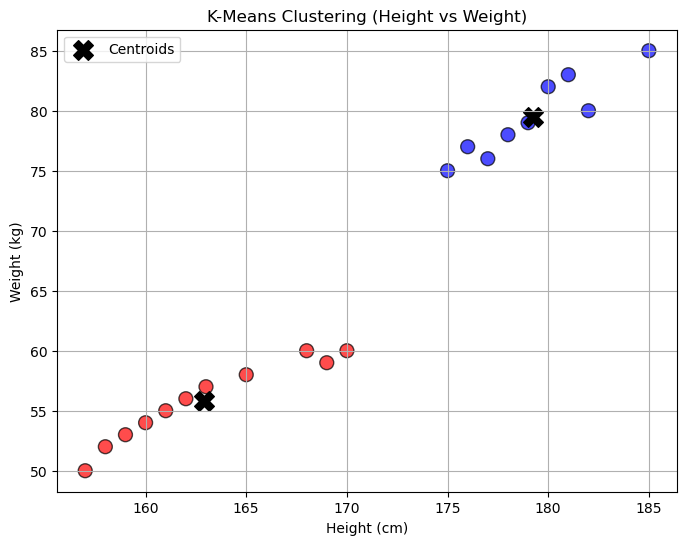

In [33]:
colors = ['red' if label == 0 else 'blue' for label in df["Cluster"]]
plt.figure(figsize=(8, 6))
plt.scatter(df["Height (cm)"], df["Weight (kg)"], c=colors, s=100, alpha=0.7, edgecolors='k')

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')

# Labels and title
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("K-Means Clustering (Height vs Weight)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:
hc = AgglomerativeClustering(n_clusters=2)
clusters = hc.fit_predict(X_scaled)
df["Cluster_HC"] = clusters

In [39]:
df

,ID,Height (cm),Weight (kg),Shoe Size (EU),Y (Gender),Cluster,Cluster_HC
0,1,161,55,37,Female,0,0
1,2,158,52,36,Female,0,0
2,3,182,80,44,Male,1,1
3,4,175,75,43,Male,1,1
4,5,165,58,38,Female,0,0
5,6,170,60,39,Female,0,0
6,7,180,82,45,Male,1,1
7,8,159,53,36,Female,0,0
8,9,177,76,42,Male,1,1
9,10,162,56,37,Female,0,0


In [41]:
true_labels = df["Y (Gender)"].map({"Female": 0, "Male": 1}).values
cm = confusion_matrix(true_labels, clusters)
ari = adjusted_rand_score(true_labels, clusters)

In [43]:
cm

array([[11,  0],
       [ 0,  9]], dtype=int64)

In [45]:
ari

1.0

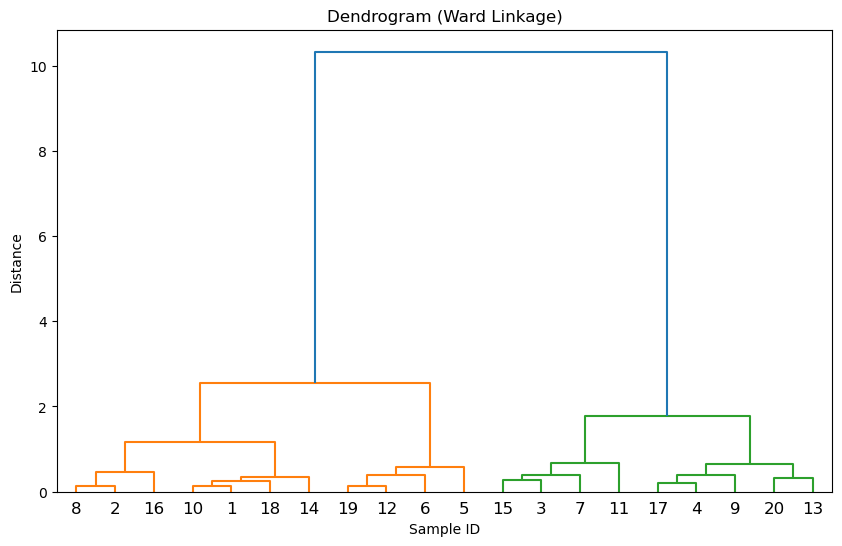

In [47]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked,
           labels=df["ID"].values,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample ID")
plt.ylabel("Distance")
plt.show()